In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Standardize features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler

# K-Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

#Evaluation metrics: accuracy and confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
# ===================== LOAD DATA =====================
try:
    # Load Titanic dataset from CSV file
    df = pd.read_csv('data/titanic.csv')
    print("Data loaded successfully.") # Optional: Confirm loading
    # Display first 5 rows to check data
    display(df.head())
except FileNotFoundError:
    # Handle missing file error
    print("ERROR: 'titanic.csv' file not found.")
    raise

Data loaded successfully.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ===================== DATA PREPROCESSING =====================

# Drop irrelevant or non-numeric columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Remove 'Embarked' column (not encoded for ML use)
df.drop('Embarked', axis=1, inplace=True)

In [4]:
# ===================== HANDLE MISSING AGE VALUES =====================

# Calculate median age for each passenger class
age_1 = df[df['Pclass'] == 1]['Age'].median()
age_2 = df[df['Pclass'] == 2]['Age'].median()
age_3 = df[df['Pclass'] == 3]['Age'].median()

# Function to fill missing Age values based on passenger class
def fill_age(row):
    # Check if Age is missing
    if pd.isnull(row['Age']):
        # Fill with median age of the corresponding class
        if row['Pclass'] == 1:
            return age_1
        if row['Pclass'] == 2:
            return age_2
        return age_3
    # Return original age if not missing
    return row['Age']

# Apply the age-filling function row-wise
df['Age'] = df.apply(fill_age, axis=1)

In [5]:
# ===================== ENCODE CATEGORICAL VARIABLES =====================

# Convert 'Sex' from string to numeric values
def fill_sex(sex):
    if sex == 'male':
        return 1
    return 0  # female

# Apply encoding to the Sex column
df['Sex'] = df['Sex'].apply(fill_sex)

In [6]:
# ===================== FEATURE / LABEL SEPARATION =====================

# Features (input variables)
X = df.drop('Survived', axis=1)

# Target variable (output label)
y = df['Survived']


# ===================== TRAIN-TEST SPLIT =====================

# Split data: 75% training, 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [7]:
# ===================== FEATURE SCALING =====================

# Create a StandardScaler object
sc = StandardScaler()

# Fit scaler on training data and transform it
X_train = sc.fit_transform(X_train)

# Transform testing data using the same scaler
X_test = sc.transform(X_test)

In [8]:
# ===================== MODEL TRAINING =====================

# Initialize KNN classifier with k = 5 neighbors
classifier = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [9]:
# ===================== PREDICTION =====================

# Predict survival outcomes on the test set
y_pred = classifier.predict(X_test)


# ===================== MODEL EVALUATION =====================

# Print model accuracy (percentage of correct predictions)
print('Percentage of correctly predicted outcomes:',
      accuracy_score(y_test, y_pred) * 100)

# Print confusion matrix
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))

Percentage of correctly predicted outcomes: 79.37219730941703

Confusion matrix:
[[114  20]
 [ 26  63]]


In [10]:
# ===================== EXPERIMENT 1: VARYING K =====================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("--- RESULTS: EXPERIMENT 1 ---")

# List of k values to test
k_values = [3, 5, 7, 9]

for k in k_values:
    # 1. Initialize model with current k
    knn_exp1 = KNeighborsClassifier(n_neighbors=k)
    
    # 2. Train model (using the previously scaled data: X_train, y_train)
    knn_exp1.fit(X_train, y_train)
    
    # 3. Predict and calculate accuracy
    y_pred_exp1 = knn_exp1.predict(X_test)
    acc = accuracy_score(y_test, y_pred_exp1) * 100
    
    print(f"k = {k} -> Accuracy: {acc:.2f}%")

--- RESULTS: EXPERIMENT 1 ---
k = 3 -> Accuracy: 78.92%
k = 5 -> Accuracy: 79.37%
k = 7 -> Accuracy: 77.58%
k = 9 -> Accuracy: 78.92%


In [11]:
# ===================== EXPERIMENT 2: NO SCALING =====================
print("\n--- RESULTS: EXPERIMENT 2 ---")

# 1. Split raw data again (X without StandardScaler applied)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 2. Train directly on raw data
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train_raw, y_train_raw)

# 3. Predict
y_pred_raw = knn_raw.predict(X_test_raw)
acc_raw = accuracy_score(y_test_raw, y_pred_raw) * 100

# Compare results
# Note: 'classifier' is the model from your original code (with scaling)
print(f"Accuracy WITH Scaling (k=5):    {accuracy_score(y_test, classifier.predict(X_test))*100:.2f}%")
print(f"Accuracy WITHOUT Scaling (k=5): {acc_raw:.2f}%")


--- RESULTS: EXPERIMENT 2 ---
Accuracy WITH Scaling (k=5):    79.37%
Accuracy WITHOUT Scaling (k=5): 70.40%


In [12]:
# ===================== EXPERIMENT 3: FEATURE ENGINEERING =====================
print("\n--- RESULTS: EXPERIMENT 3 ---")

# 1. RELOAD DATA TO RECOVER 'EMBARKED' COLUMN
df_new = pd.read_csv('data/titanic.csv')

# --- Basic Preprocessing (Same as before) ---
df_new['Sex'] = df_new['Sex'].apply(lambda x: 1 if x == 'male' else 0)
df_new['Age'] = df_new['Age'].fillna(df_new['Age'].median()) 
df_new.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# --- NEW PART: CREATE FEATURES ---

# 3a. Create FamilySize (SibSp + Parch + Self)
df_new['FamilySize'] = df_new['SibSp'] + df_new['Parch'] + 1

# 3b. Process Embarked
df_new['Embarked'] = df_new['Embarked'].fillna('S') # Fill missing with 'S'
# One-Hot Encoding for Embarked
df_new = pd.get_dummies(df_new, columns=['Embarked'], drop_first=True)

# 2. PREPARE X AND y
X_new = df_new.drop('Survived', axis=1)
y_new = df_new['Survived']

# 3. RUN THE PIPELINE (Split -> Scale -> Train)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.25, random_state=42
)

# Important: We must scale the new features too!
sc_new = StandardScaler()
X_train_new = sc_new.fit_transform(X_train_new)
X_test_new = sc_new.transform(X_test_new)

# 4. TRAIN WITH K=5 (To compare with Baseline)
knn_new = KNeighborsClassifier(n_neighbors=5)
knn_new.fit(X_train_new, y_train_new)

acc_new = accuracy_score(y_test_new, knn_new.predict(X_test_new)) * 100
print(f"Accuracy with New Features (FamilySize, Embarked): {acc_new:.2f}%")


--- RESULTS: EXPERIMENT 3 ---
Accuracy with New Features (FamilySize, Embarked): 81.17%


In [13]:
# ===================== LOAD & FEATURE ENGINEERING =====================
# Reload data to get the 'Name' column back
df = pd.read_csv('data/titanic.csv')

# --- 1. Extract 'Title' from 'Name' ---
# Extract the word between the comma and the dot (e.g., "Mr", "Miss")
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles into 'Other' to reduce noise
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 
               'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Other')

# Normalize French titles or synonyms
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Map Titles to numbers
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Other": 5}
df['Title'] = df['Title'].map(title_mapping)
df['Title'] = df['Title'].fillna(0)

# --- 2. Clean Data ---
# Now we can safely drop 'Name' along with other unused columns
df.drop(['Name', 'PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Fill missing Embarked with 'S' (Most frequent)
df['Embarked'] = df['Embarked'].fillna('S')

# Fill missing Fare with Median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Fill missing Age using the Median of each Pclass (Smarter imputation)
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median')) #Issue: groupby().median() cannot be used directly

# --- 3. Encode Categorical Variables ---
# Convert 'Sex': Male=1, Female=0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0}).astype(int)

# Convert 'Embarked': S=0, C=1, Q=2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

print("Feature Engineering completed. New 'Title' column added.")
display(df.head())

Feature Engineering completed. New 'Title' column added.


<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
C:\Users\PC\AppData\Local\Temp\ipykernel_32472\3999581576.py:7: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,1,3
2,1,3,0,26.0,0,0,7.9250,0,2
3,1,1,0,35.0,1,0,53.1000,0,3
4,0,3,1,35.0,0,0,8.0500,0,1


In [14]:
# ===================== MODEL TRAINING (RANDOM FOREST) =====================
# Import necessary libraries for Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Split Data
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split 80% Train, 20% Test (RF works better with more training data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scaling (Optional for Random Forest, but good practice)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 3. Initialize Random Forest Model
# n_estimators=100: Create 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


Random Forest Accuracy: 82.12%

Confusion Matrix:
[[89 16]
 [16 58]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



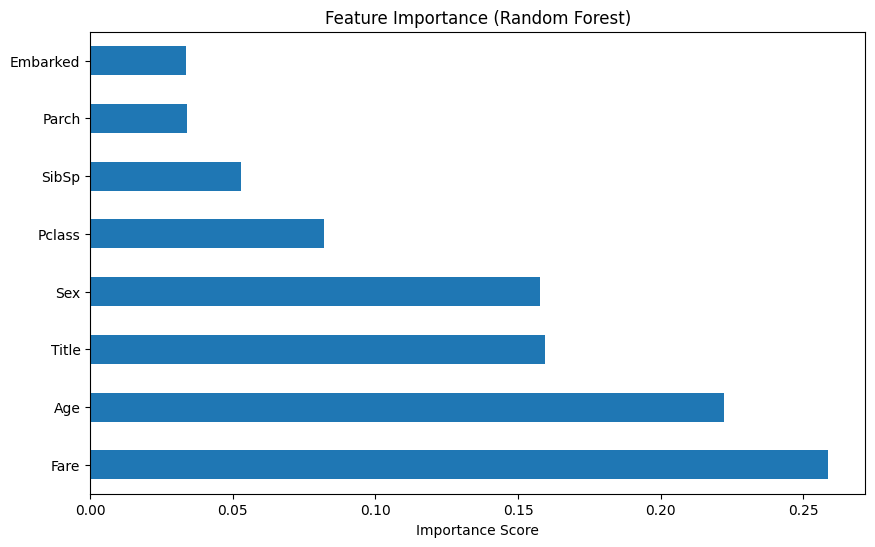

In [15]:
# ===================== EVALUATION & VISUALIZATION =====================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predict
y_pred = rf_model.predict(X_test)

# 2. Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc * 100:.2f}%")

# 3. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 4. Classification Report (Detailed metrics)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# --- NEW: FEATURE IMPORTANCE PLOT ---
# Visualizing which factors contributed most to survival
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

In [16]:
import pickle

# Lưu mô hình Random Forest
pickle.dump(rf_model, open('rf_model.pkl', 'wb'))

# Lưu luôn cái cân (Scaler) để mốt nhập liệu trên web còn biết đường chuẩn hóa
pickle.dump(sc, open('scaler.pkl', 'wb'))

print("Đã lưu thành công mô hình và scaler!")

Đã lưu thành công mô hình và scaler!
